# Adaptive Fusion Portfolio Optimisation System (POC), No Periodic Retraining
**By: Alasteir Ho** 


---

### Pipeline overview
| # | Section | Description |
|---|---------|-------------|
| 1 | Configuration | All tunable parameters |
| 2 | Price & Sentiment Data | yfinance daily OHLCV + sentiment CSVs |
| 3 | Feature Engineering | RSI, MACD, Bollinger, momentum, Z-scores, context |
| 4 | Adaptive Fusion Network | PyTorch attention-based fusion (train + inference) |
| 5 | Portfolio Optimiser | Black-Litterman + Sharpe-ratio maximisation (SLSQP) |
| 6 | Backtest Engine | Event-driven backtest with real execution prices |
| 7 | Benchmarks | SPY B&H, Equal-Weight |
| 8 | Run All Strategies | Execute full pipeline (all 5 strategies) |
| 9 | Results & Visualisations | 5 figures + metrics summary table |
| 10 | Rolling Window Analysis | Sensitivity of performance to backtest entry date |

## 1. Configuration
All tunable parameters in one place â€” the only section you need to edit.

| Group | Key parameters |
|-------|----------------|
| **Paths** | Directories for news/tweet sentiment CSVs and yfinance price data |
| **Universe** | 20 large-cap tickers across 7 GICS sectors |
| **Dates** | Training data `2023-10-10` to `2025-02-10`; backtest period `2025-02-10` to `2026-02-10` |
| **Execution** | 5 bps one-way slippage, SEC fee (0.278 bps of sell proceeds), FINRA TAF ($0.000166/share) |
| **Portfolio** | Top-5 stock selection per rebalance, weight bounds [5 %, 20 %], 10-day rebalance frequency |
| **Neural network** | 6 factors, context dim 32, hidden dim 16, up to 75 epochs with early stopping (patience 25) |
| **Black-Litterman** | Ï„ = 0.5 (prior uncertainty), Î´ = 2.5 (risk-aversion), Î©_scale = 1.0 (equal prior / view weight) |

In [40]:
from pathlib import Path
import torch

RETRAIN = True    # True  - retrain; False - load saved model if available

INITIAL_NAV = 10_000.0 # Nominal Account Value

NOTEBOOK_DIR         = Path().resolve()
FYP_DIR              = NOTEBOOK_DIR.parent          # one level up to FYP root
NEWS_SENTIMENT_DIR   = FYP_DIR / "Processed_Data" / "news_sentiment_daily"
SOCIAL_SENTIMENT_DIR = FYP_DIR / "Processed_Data" / "tweets_sentiment_daily"
OUTPUT_DIR           = NOTEBOOK_DIR / "outputs"
MODEL_PATH           = NOTEBOOK_DIR / "fusion_network.pt"
OUTPUT_DIR.mkdir(exist_ok=True)

DATE_COL            = "date"
SENTIMENT_SCORE_COL = "avg_sentiment"   # column name in both news and tweet CSVs
NEWS_CSV_SUFFIX     = "_news_sentiment_daily.csv"
SOCIAL_CSV_SUFFIX   = "_tweets_sentiment_daily.csv"

TICKERS = [
    "AAPL","AMZN","AVGO","BRK-B","GOOGL",
    "HD",  "JNJ", "JPM", "LLY",  "MA",
    "META","MSFT","NVDA","ORCL", "PG",
    "TSLA","UNH", "V",   "WMT",  "XOM",
]

SECTOR_MAP = {
    "AAPL":"Technology",  "AVGO":"Technology",  "MSFT":"Technology",
    "NVDA":"Technology",  "ORCL":"Technology",
    "AMZN":"ConsumerDiscretionary","HD":"ConsumerDiscretionary","TSLA":"ConsumerDiscretionary",
    "GOOGL":"Communication","META":"Communication",
    "BRK-B":"Financials","JPM":"Financials","MA":"Financials","V":"Financials",
    "JNJ":"Healthcare",  "LLY":"Healthcare",  "UNH":"Healthcare",
    "PG":"ConsumerStaples","WMT":"ConsumerStaples",
    "XOM":"Energy",
}
SECTORS = sorted(set(SECTOR_MAP.values()))

DATA_START     = "2023-10-10"
BACKTEST_START = "2024-10-10"
BACKTEST_END   = "2026-02-16"
TRAIN_END      = BACKTEST_START

TOP_N_STOCKS   = 5
MIN_WEIGHT     = 0.05
MAX_WEIGHT     = 0.20
REBALANCE_DAYS = 10

# Execution price = yfinance daily Open + SLIPPAGE_BPS (Simulate realistic execution with slippage)
SLIPPAGE_BPS      = 5           # one-way slippage estimate (bps)
SEC_FEE_RATE      = 0.0000278   # SEC fee per $ of sell proceeds
FINRA_TAF_PER_SH  = 0.000166    # FINRA TAF per share sold (capped $8.30)

RSI_PERIOD        = 14
MACD_FAST         = 12
MACD_SLOW         = 26
MACD_SIGNAL       = 9
BB_PERIOD         = 20
BB_STD            = 2
MOMENTUM_PERIOD   = 20
VOLATILITY_WINDOW = 20

N_FACTORS     = 6
CONTEXT_DIM   = 32
HIDDEN_DIM    = 16
LEARNING_RATE = 1e-3
TRAIN_EPOCHS  = 75
BATCH_SIZE    = 64
DROPOUT_RATE  = 0.2
WEIGHT_DECAY  = 1e-4
RANDOM_SEED   = 42
STATIC_WEIGHTS = [0.20, 0.15, 0.15, 0.15, 0.20, 0.15]

# --- Black-Litterman parameters ---
BL_TAU         = 0.5   # prior uncertainty scalar (0.5 chosen for daily returns;
                        # smaller values give more weight to the equilibrium prior)
BL_DELTA       = 2.5   # implied market risk-aversion coefficient
BL_OMEGA_SCALE = 1.0   # view uncertainty relative to Ï„Î£:
                        #   < 1 â†’ trust model views more
                        #   1   â†’ equal weight (prior / views)
                        #   > 1 â†’ trust equilibrium prior more

DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BENCHMARK_TICKER = "SPY"
RISK_FREE_RATE   = 0.0

FACTOR_COLS = [
    "z_news_sentiment","z_social_sentiment",
    "z_rsi","z_macd","z_momentum","z_bb_width",
]
CONTEXT_COLS = (
    ["volatility_regime","news_intensity","social_intensity"]
    + [f"sector_{s}" for s in SECTORS]
)

if DEVICE == "cuda":
    device_name = torch.cuda.get_device_name(0)
else:
    device_name = "CPU"
    

print(f"Device         : {DEVICE} ({device_name})")
print(f"Tickers        : {len(TICKERS)}")
print(f"Backtest       : {BACKTEST_START} to {BACKTEST_END}")
print(f"Execution price: yfinance daily Open + {SLIPPAGE_BPS} bps slippage")
print(f"News dir       : {NEWS_SENTIMENT_DIR}")
print(f"Social dir     : {SOCIAL_SENTIMENT_DIR}")
print(f"News dir exists  : {NEWS_SENTIMENT_DIR.exists()}")
print(f"Social dir exists: {SOCIAL_SENTIMENT_DIR.exists()}")


Device         : cuda (NVIDIA GeForce RTX 5080)
Tickers        : 20
Backtest       : 2024-10-10 to 2026-02-16
Execution price: yfinance daily Open + 5 bps slippage
News dir       : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir     : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
News dir exists  : True
Social dir exists: True


---
## 2. Price & Sentiment Data (yfinance)
Daily OHLCV fetched via yfinance for all 20 tickers. Sentiment CSVs are loaded from
`Processed_Data/` and aligned to the price index, then shifted forward by one trading day
so no same-day sentiment leaks into the feature set.

In [41]:
import logging, warnings
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

def fetch_price_data(tickers, start, end):
    price_data = {}
    print(f"Fetching daily OHLCV for {len(tickers)} tickers ...", end=" ")
    for ticker in tickers:
        try:
            raw = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
            if raw.empty: continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).normalize()
            price_data[ticker] = raw[["Open","High","Low","Close","Volume"]].copy()
        except Exception as error:
            print(f"\n  Warning: {ticker} - {error}")
    print(f"done ({len(price_data)}/{len(tickers)})")
    return price_data

def _load_csv(path, label):
    if not path.exists(): return None
    try:
        df = pd.read_csv(path, parse_dates=[DATE_COL])
        df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.normalize()
        df = df.drop_duplicates(DATE_COL).set_index(DATE_COL)
        sentiment_series      = df[SENTIMENT_SCORE_COL].astype(float)
        sentiment_series.name = label
        return sentiment_series
    except: return None

def _social_ticker(ticker):
    """Normalise ticker for social CSV filenames (e.g. BRK-B -> BRK.B)."""
    return ticker.replace("-", ".")

def load_sentiment_data(tickers, start, end, news_dir, social_dir):
    print(f"News dir    : {news_dir}")
    print(f"Social dir  : {social_dir}")
    date_range = pd.bdate_range(start=start, end=end, freq="C")
    sentiment  = {}
    missing_news, missing_social = [], []
    for ticker in tickers:
        news_path   = news_dir   / f"{ticker}{NEWS_CSV_SUFFIX}"
        social_path = social_dir / f"{_social_ticker(ticker)}{SOCIAL_CSV_SUFFIX}"
        news_series   = _load_csv(news_path,   "news_sentiment")
        social_series = _load_csv(social_path, "social_sentiment")
        if news_series   is None: missing_news.append(ticker)
        if social_series is None: missing_social.append(ticker)
        aligned_df = pd.DataFrame(index=date_range)
        aligned_df["news_sentiment"]   = news_series.reindex(date_range)   if news_series   is not None else 0.0
        aligned_df["social_sentiment"] = social_series.reindex(date_range) if social_series is not None else 0.0
        aligned_df["news_available"]   = (news_series.reindex(date_range).notna().astype(float)
                                          if news_series is not None else 0.0)
        sentiment[ticker] = aligned_df.ffill(limit=3).fillna(0.0).clip(-1.0, 1.0)
    print(f"Loaded sentiment for {len(sentiment)}/{len(tickers)} tickers")
    if missing_news:   print(f"  Missing news CSVs  : {missing_news}")
    if missing_social: print(f"  Missing social CSVs: {missing_social}")
    return sentiment

def build_master_dataset(price_data, sentiment_data):
    master = {}
    for ticker in price_data:
        price_df = price_data[ticker].copy()
        if ticker in sentiment_data:
            merged = price_df.join(sentiment_data[ticker].shift(1), how="left")  # +1 day shift
        else:
            merged = price_df.copy()
            merged[["news_sentiment","social_sentiment","news_available"]] = 0.0
        master[ticker] = merged.ffill(limit=3).fillna(0.0)
    return master

def fetch_spy_returns(start, end):
    spy = yf.download(BENCHMARK_TICKER, start=start, end=end,
                      auto_adjust=True, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    spy.index = pd.to_datetime(spy.index).normalize()
    return spy["Close"].pct_change().dropna().rename("SPY")

price_data     = fetch_price_data(TICKERS, DATA_START, BACKTEST_END)
spy_returns    = fetch_spy_returns(BACKTEST_START, BACKTEST_END)
sentiment_data = load_sentiment_data(TICKERS, DATA_START, BACKTEST_END,
                                     NEWS_SENTIMENT_DIR, SOCIAL_SENTIMENT_DIR)
master_data    = build_master_dataset(price_data, sentiment_data)
print(f"\nMaster dataset ready: {len(master_data)} tickers")

Fetching daily OHLCV for 20 tickers ... done (20/20)
News dir    : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\news_sentiment_daily
Social dir  : C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily
Loaded sentiment for 20/20 tickers

Master dataset ready: 20 tickers


---
## 3 Feature Engineering

Six Z-scored factors for the fusion network, plus context features for the attention encoder.  
All Z-scores use **expanding windows** (no look-ahead bias at any point).

| Factor | Source | Literature |
|--------|--------|-----------|
| News sentiment (Z) | FinBERT / GDELT | Araci (2019), Shen et al. (2022) |
| Social sentiment (Z) | FinRoBERTa / Twitter | Bollen et al. (2011) |
| RSI (Z) | Close price | Wilder (1978) |
| MACD (Z) | Close price | Appel (2005) |
| Momentum 20d (Z) | Close price | Jegadeesh & Titman (1993) |
| Bollinger Band width (Z) | Close price | Bollinger (1992) |

Context features fed to the attention encoder: volatility regime (low/mid/high tercile), news intensity (5-day rolling coverage), social intensity (5-day rolling absolute sentiment), and 7 sector one-hot encoded sectors, totalling 10 inputs.

In [42]:
def compute_rsi(close, period=RSI_PERIOD):
    price_delta       = close.diff()
    avg_gain          = price_delta.clip(lower=0).ewm(com=period-1, min_periods=period).mean()
    avg_loss          = (-price_delta.clip(upper=0)).ewm(com=period-1, min_periods=period).mean()
    relative_strength = avg_gain / avg_loss.replace(0, np.nan)
    return ((100 - 100 / (1 + relative_strength)) - 50) / 50

def compute_macd(close):
    macd_histogram  = (close.ewm(span=MACD_FAST, adjust=False).mean()
                      - close.ewm(span=MACD_SLOW, adjust=False).mean())
    macd_histogram -= macd_histogram.ewm(span=MACD_SIGNAL, adjust=False).mean()
    return (macd_histogram / close).fillna(0)

def compute_bb_width(close):
    simple_moving_avg = close.rolling(BB_PERIOD).mean()
    return ((2 * BB_STD * close.rolling(BB_PERIOD).std()) / simple_moving_avg.replace(0, np.nan)).fillna(0)

def compute_momentum(close):
    return close.pct_change(MOMENTUM_PERIOD).fillna(0)

def compute_vol_regime(close):
    realized_volatility = close.pct_change().rolling(VOLATILITY_WINDOW).std()
    quantile_33         = realized_volatility.expanding().quantile(0.33)
    quantile_66         = realized_volatility.expanding().quantile(0.66)
    regime_series       = pd.Series(1, index=close.index)
    regime_series[realized_volatility <= quantile_33] = 0
    regime_series[realized_volatility >  quantile_66] = 2
    return regime_series.astype(float)

def expanding_zscore(series, min_periods=30):
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std  = series.expanding(min_periods=min_periods).std().replace(0, np.nan)
    return ((series - expanding_mean) / expanding_std).clip(-3, 3).fillna(0)

def sector_onehot(ticker):
    one_hot_vector = np.zeros(len(SECTORS), dtype=np.float32)
    sector_name    = SECTOR_MAP.get(ticker, SECTORS[0])
    if sector_name in SECTORS: one_hot_vector[SECTORS.index(sector_name)] = 1.0
    return one_hot_vector

def build_features(master):
    all_features = {}
    for ticker, df in master.items():
        ticker_df = df.copy()
        ticker_df["rsi"]        = compute_rsi(ticker_df["Close"])
        ticker_df["macd"]       = compute_macd(ticker_df["Close"])
        ticker_df["bb_width"]   = compute_bb_width(ticker_df["Close"])
        ticker_df["momentum"]   = compute_momentum(ticker_df["Close"])
        ticker_df["vol_regime"] = compute_vol_regime(ticker_df["Close"])

        ticker_df["z_news_sentiment"]   = expanding_zscore(ticker_df["news_sentiment"])
        ticker_df["z_social_sentiment"] = expanding_zscore(ticker_df["social_sentiment"])
        ticker_df["z_rsi"]              = expanding_zscore(ticker_df["rsi"])
        ticker_df["z_macd"]             = expanding_zscore(ticker_df["macd"])
        ticker_df["z_momentum"]         = expanding_zscore(ticker_df["momentum"])
        ticker_df["z_bb_width"]         = expanding_zscore(ticker_df["bb_width"])

        ticker_df["volatility_regime"] = ticker_df["vol_regime"]
        ticker_df["news_intensity"]    = ticker_df["news_available"].rolling(5).mean().fillna(0)
        ticker_df["social_intensity"]  = ticker_df["social_sentiment"].abs().rolling(5).mean().fillna(0)
        one_hot_vector = sector_onehot(ticker)
        for sector_idx, sector_label in enumerate(SECTORS):
            ticker_df[f"sector_{sector_label}"] = one_hot_vector[sector_idx]

        ticker_df["fwd_return_1d"] = ticker_df["Close"].pct_change(1).shift(-1)
        all_features[ticker] = ticker_df

    print(f"Features built: {len(all_features)} tickers \u00d7 "
          f"{len(next(iter(all_features.values())).columns)} columns")
    return all_features

feature_data = build_features(master_data)
print(f"Sample (AAPL, last row):")
print(feature_data["NVDA"][FACTOR_COLS + ["Close"]].tail(1).to_string())

Features built: 20 tickers × 30 columns
Sample (AAPL, last row):
            z_news_sentiment  z_social_sentiment     z_rsi   z_macd  z_momentum  z_bb_width       Close
Date                                                                                                   
2026-02-13          1.290262           -1.720185 -0.798354  0.03772   -0.635969   -0.742655  182.809998


---
## 4 · Adaptive Fusion Network (PyTorch)

A context-conditioned attention network that learns to reweight the six Z-scored factors based on
current market regime (volatility, sector, sentiment intensity). At each rebalance, the network
produces a single composite score per ticker; the portfolio optimiser uses these scores as
Black-Litterman views.

### 4a · Architecture

```
Context (10d) -> Linear(10->32) -> ReLU -> Dropout       [Context Encoder]
             -> Linear(32->16) -> ReLU -> Linear(16->6)   [Attention Generator]
             -> Softmax                                    [attention weights sum to 1]
             -> sum(w_i * z_factor_i)                     [Weighted Fusion: composite score]
```

The 10 context inputs are: volatility regime, news intensity, social intensity, and one-hot sector (7 classes).  
The 6 attention weights are learned per-sample, so different market regimes produce different factor weightings.

In [43]:
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(RANDOM_SEED)


class AdaptiveFusionNetwork(nn.Module):
    """Context-conditioned attention network that reweights six Z-scored factors per market regime."""

    def __init__(self, context_size):
        super().__init__()
        self.context_encoder = nn.Sequential(
            nn.Linear(context_size, CONTEXT_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
        )
        self.attention_head = nn.Sequential(
            nn.Linear(CONTEXT_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, N_FACTORS),
            nn.Softmax(dim=-1),
        )

    def forward(self, factors, context):
        context_encoded   = self.context_encoder(context)              # (batch, CONTEXT_DIM)
        attention_weights = self.attention_head(context_encoded)       # (batch, N_FACTORS)
        composite_score   = (attention_weights * factors).sum(dim=-1)  # (batch,) weighted composite
        return composite_score, attention_weights


def get_composite_scores(model, feature_data, date, tickers):
    """
    Run inference for all tickers on a single rebalance date.

    Returns
    -------
    scores         : dict {ticker: composite_score}
    mean_attention : dict {factor_name: mean_attention_weight}  (averaged across tickers)
    """
    scores, attention_list = {}, []
    model.eval()
    with torch.no_grad():
        for ticker in tickers:
            ticker_df = feature_data.get(ticker)
            if ticker_df is None or date not in ticker_df.index:
                continue
            row            = ticker_df.loc[date]
            factor_tensor  = torch.tensor(
                row[FACTOR_COLS].values.astype(np.float32)
            ).unsqueeze(0).to(DEVICE)
            context_tensor = torch.tensor(
                row[CONTEXT_COLS].values.astype(np.float32)
            ).unsqueeze(0).to(DEVICE)
            composite_score, attention = model(factor_tensor, context_tensor)
            scores[ticker] = float(composite_score.squeeze().cpu().item())
            attention_list.append(attention.squeeze().cpu().numpy())

    mean_attention = {}
    if attention_list:
        mean_weights   = np.stack(attention_list).mean(axis=0)
        mean_attention = {factor: float(weight) for factor, weight in zip(FACTOR_COLS, mean_weights)}

    return scores, mean_attention


print("AdaptiveFusionNetwork defined.")
print(f"  Context size : {len(CONTEXT_COLS)}")
print(f"  N factors    : {N_FACTORS}")
print(f"  Architecture : Linear({len(CONTEXT_COLS)}\u2192{CONTEXT_DIM}) \u2192 ReLU \u2192 Dropout \u2192")
print(f"                 Linear({CONTEXT_DIM}\u2192{HIDDEN_DIM}) \u2192 ReLU \u2192 Linear({HIDDEN_DIM}\u2192{N_FACTORS}) \u2192 Softmax")

AdaptiveFusionNetwork defined.
  Context size : 10
  N factors    : 6
  Architecture : Linear(10→32) → ReLU → Dropout →
                 Linear(32→16) → ReLU → Linear(16→6) → Softmax


### 4b · Training: Cross-Sectional Rank-IC Loss

The network is trained to **rank** stocks correctly relative to each other on a given day, not to
predict absolute returns. Each mini-batch groups `k_dates` complete trading days so the IC
(information coefficient) is always computed cross-sectionally, across tickers on the same date.
This prevents the model from learning time-series trends (e.g. "NVDA always scores high") that do
not translate to out-of-sample cross-sectional alpha.

**Training targets:** vol-adjusted 1-day forward returns, winsorised to the 2nd-98th percentile.  
**Val set:** strict temporal holdout, last 15% of training dates (no shuffling).  
**Early stopping:** patience = 25 epochs; best-val-IC model state is restored before inference.

In [44]:
def build_train_tensors(feature_data, train_end=None, min_rows=60, verbose=True):
    """
    Build per-date cross-sectional training groups.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.
        Pass the current rebalance date for walk-forward validation.

    Returns train_groups and val_groups: each is a list of
    (factors, context, targets) tensors -- one tuple per trading date, rows = available tickers.
    """
    cutoff = pd.Timestamp(train_end) if train_end is not None else pd.Timestamp(TRAIN_END)

    all_rows = []
    for ticker, df in feature_data.items():
        mask          = (df.index >= DATA_START) & (df.index < cutoff)
        ticker_subset = df[mask].dropna(subset=FACTOR_COLS + CONTEXT_COLS + ["fwd_return_1d"])
        if len(ticker_subset) < min_rows:
            continue

        rolling_vol = (ticker_subset["fwd_return_1d"]
                       .expanding(min_periods=20).std()
                       .replace(0, np.nan).ffill()
                       .fillna(ticker_subset["fwd_return_1d"].std()))
        adj_returns = (ticker_subset["fwd_return_1d"] / rolling_vol).clip(-3, 3)

        for date, row in ticker_subset.iterrows():
            all_rows.append({
                "date":    date,
                "factors": row[FACTOR_COLS].values.astype(np.float32),
                "context": row[CONTEXT_COLS].values.astype(np.float32),
                "target":  float(adj_returns.loc[date]),
            })

    all_rows.sort(key=lambda sample: sample["date"])

    # Winsorise residual outliers
    all_targets               = np.array([sample["target"] for sample in all_rows], dtype=np.float32)
    lower_bound, upper_bound  = np.percentile(all_targets, 2), np.percentile(all_targets, 98)
    for sample in all_rows:
        sample["target"] = float(np.clip(sample["target"], lower_bound, upper_bound))

    n_val   = max(int(len(all_rows) * 0.15), 1)
    n_train = len(all_rows) - n_val
    cutoff_date  = all_rows[n_train]["date"]

    if verbose:
        print(f"Training set : {n_train:,} samples from {len(feature_data)} tickers")
        print(f"Val set      : {n_val:,} samples  (dates >= {cutoff_date.date()} - true holdout)")
        print(f"Target range : [{all_targets.min():.3f}, {all_targets.max():.3f}] (vol-adjusted returns)")

    def to_date_groups(rows):
        by_date = {}
        for sample in rows:
            by_date.setdefault(sample["date"], []).append(sample)
        return [
            (torch.tensor(np.stack([sample["factors"] for sample in date_samples])),
             torch.tensor(np.stack([sample["context"] for sample in date_samples])),
             torch.tensor(np.array([sample["target"]  for sample in date_samples], dtype=np.float32)))
            for date_samples in [by_date[group_date] for group_date in sorted(by_date.keys())]
        ]

    return to_date_groups(all_rows[:n_train]), to_date_groups(all_rows[n_train:])


def rank_ic_loss(predictions, targets):
    """Pearson IC for one cross-section. Returns negative IC so minimisation == IC maximisation."""
    pred_centered   = predictions - predictions.mean()
    target_centered = targets     - targets.mean()
    return -(pred_centered * target_centered).sum() / (pred_centered.norm() * target_centered.norm() + 1e-8)


def train_model(feature_data, train_end=None, verbose=True, k_dates=3):
    """
    Train the fusion network using cross-sectional rank-IC loss.

    Parameters
    ----------
    train_end : str or Timestamp, optional
        Exclusive upper bound for training data. Defaults to global TRAIN_END.
        Pass the current rebalance date for walk-forward retraining.
    verbose : bool
        If False, suppresses per-epoch output. Used during rolling retraining
        to avoid flooding the notebook with training logs.
    """
    train_groups, val_groups = build_train_tensors(feature_data, train_end=train_end, verbose=verbose)

    context_size = train_groups[0][1].shape[1]
    model        = AdaptiveFusionNetwork(context_size).to(DEVICE)
    optimizer    = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
    scheduler    = optim.lr_scheduler.ReduceLROnPlateau(
                       optimizer, patience=10, factor=0.5, min_lr=1e-5)

    best_val_loss, best_state, patience_counter = float("inf"), None, 0
    EARLY_STOP = 25
    train_ic_history, val_ic_history = [], []

    if verbose:
        device_label = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE
        print(f"\nTraining on {device_label} (cross-sectional rank-IC) "
              f"for up to {TRAIN_EPOCHS} epochs ...")

    for epoch in range(1, TRAIN_EPOCHS + 1):
        model.train()
        permutation   = np.random.permutation(len(train_groups))
        train_ic_list = []

        for batch_start in range(0, len(permutation) - k_dates + 1, k_dates):
            optimizer.zero_grad()
            batch_losses = []
            for group_index in permutation[batch_start:batch_start + k_dates]:
                factor_batch, context_batch, target_batch = (
                    train_groups[group_index][0].to(DEVICE),
                    train_groups[group_index][1].to(DEVICE),
                    train_groups[group_index][2].to(DEVICE))
                if len(target_batch) < 4:
                    continue
                date_loss = rank_ic_loss(model(factor_batch, context_batch)[0], target_batch)
                batch_losses.append(date_loss)
                train_ic_list.append(-date_loss.item())
            if not batch_losses:
                continue
            torch.stack(batch_losses).mean().backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_ic_list = []
        with torch.no_grad():
            for factor_batch, context_batch, target_batch in val_groups:
                factor_batch  = factor_batch.to(DEVICE)
                context_batch = context_batch.to(DEVICE)
                target_batch  = target_batch.to(DEVICE)
                if len(target_batch) >= 4:
                    val_ic_list.append(
                        -rank_ic_loss(model(factor_batch, context_batch)[0], target_batch).item())

        train_ic = float(np.mean(train_ic_list)) if train_ic_list else 0.0
        val_ic   = float(np.mean(val_ic_list))   if val_ic_list   else 0.0
        train_ic_history.append(-train_ic)
        val_ic_history.append(-val_ic)

        scheduler.step(-val_ic)

        if -val_ic < best_val_loss:
            best_val_loss, patience_counter = -val_ic, 0
            best_state = {key: value.clone() for key, value in model.state_dict().items()}
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"  Epoch {epoch:3d} | train IC={train_ic:.4f} | val IC={val_ic:.4f} "
                  f"| gap={train_ic - val_ic:+.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")

        if patience_counter >= EARLY_STOP:
            if verbose:
                print(f"  Early stop at epoch {epoch} (best val IC: {-best_val_loss:.4f})")
            break

    model.load_state_dict(best_state)
    model.eval()

    train_ic_final = float(np.mean(train_ic_list)) if train_ic_list else 0.0
    val_ic_final   = -best_val_loss
    if verbose:
        print(f"\nTraining complete.")
        print(f"  Best val IC: {val_ic_final:.4f}  (positive = model has predictive signal)")
        print(f"  Final gap  : {train_ic_final - val_ic_final:+.4f}  "
              f"({'overfit' if train_ic_final - val_ic_final > 0.10 else 'healthy'})")

    return model, train_ic_history, val_ic_history


# --- train or load ---
train_ic_history, val_ic_history = [], []   # populated only when RETRAIN=True
if not RETRAIN and MODEL_PATH.exists():
    print("Loading saved model ...")
    fusion_model = AdaptiveFusionNetwork(len(CONTEXT_COLS))
    fusion_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    fusion_model.to(DEVICE).eval()
else:
    fusion_model, train_ic_history, val_ic_history = train_model(feature_data)
    torch.save(fusion_model.state_dict(), MODEL_PATH)
    print(f"\nModel saved: {MODEL_PATH.name}")


Training set : 4,284 samples from 20 tickers
Val set      : 756 samples  (dates >= 2024-08-16 - true holdout)
Target range : [-3.000, 3.000] (vol-adjusted returns)

Training on NVIDIA GeForce RTX 5080 (cross-sectional rank-IC) for up to 75 epochs ...
  Epoch   1 | train IC=-0.0132 | val IC=-0.0175 | gap=+0.0043 | lr=1.00e-03
  Epoch  10 | train IC=0.0235 | val IC=0.0068 | gap=+0.0167 | lr=1.00e-03
  Epoch  20 | train IC=0.0319 | val IC=0.0103 | gap=+0.0216 | lr=1.00e-03
  Epoch  30 | train IC=0.0320 | val IC=0.0069 | gap=+0.0251 | lr=5.00e-04
  Epoch  40 | train IC=0.0421 | val IC=0.0019 | gap=+0.0402 | lr=2.50e-04
  Early stop at epoch 43 (best val IC: 0.0103)

Training complete.
  Best val IC: 0.0103  (positive = model has predictive signal)
  Final gap  : +0.0312  (healthy)

Model saved: fusion_network.pt


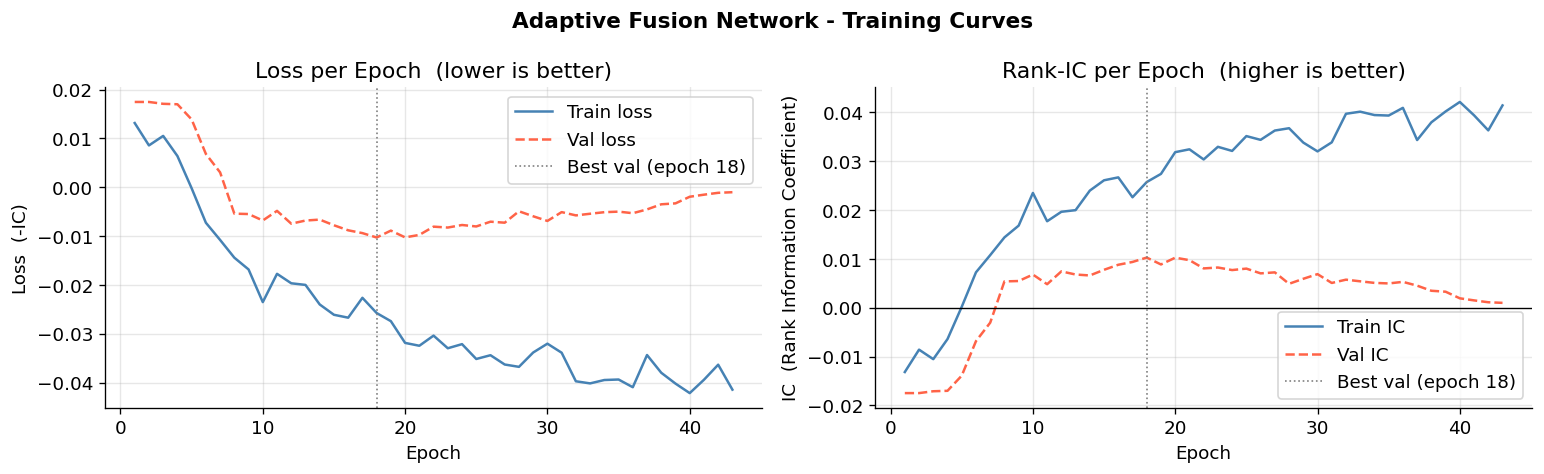

Best val IC   : 0.0103  at epoch 18
Final train IC: 0.0414
Overfit gap   : +0.0312   (healthy)


In [45]:
# Training curves (only available after a fresh training run)
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

if train_ic_history and val_ic_history:
    epochs = range(1, len(train_ic_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Adaptive Fusion Network - Training Curves", fontsize=13, fontweight="bold")

    # --- Loss (negative IC; lower is better) ---
    ax = axes[0]
    ax.plot(epochs, train_ic_history, label="Train loss", color="steelblue")
    ax.plot(epochs, val_ic_history,   label="Val loss",   color="tomato", linestyle="--")
    best_epoch = int(min(range(len(val_ic_history)), key=lambda i: val_ic_history[i])) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss  (-IC)")
    ax.set_title("Loss per Epoch  (lower is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- IC (positive; higher is better) ---
    ax = axes[1]
    ax.plot(epochs, [-v for v in train_ic_history], label="Train IC", color="steelblue")
    ax.plot(epochs, [-v for v in val_ic_history],   label="Val IC",   color="tomato", linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1, label=f"Best val (epoch {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("IC  (Rank Information Coefficient)")
    ax.set_title("Rank-IC per Epoch  (higher is better)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_val_ic = max(-v for v in val_ic_history)
    final_train_ic = -train_ic_history[-1]
    print(f"Best val IC   : {best_val_ic:.4f}  at epoch {best_epoch}")
    print(f"Final train IC: {final_train_ic:.4f}")
    print(f"Overfit gap   : {final_train_ic - best_val_ic:+.4f}  ",
          "(overfit)" if final_train_ic - best_val_ic > 0.10 else "(healthy)")
else:
    print("No training history available. Set RETRAIN=True and re-run cell 10 to generate curves.")


---
## 5 · Portfolio Optimiser (Black-Litterman + Sharpe MVO)

$$\mu_{BL} = \pi + \tau\Sigma\,(\tau\Sigma + \Omega)^{-1}(Q - \pi)$$

$$S(\mathbf{w}) = \frac{\mathbf{w}^\top \boldsymbol{\mu}_{BL}}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}}$$

Constraints: $\sum w_i = 1$, $\ w_i \in [5\%,\ 20\%]$

| Symbol | Meaning |
|--------|---------|
| $\pi = \delta\Sigma w_{eq}$ | Equilibrium prior (equal-weight reference, $\delta=2.5$) |
| $Q$ | Absolute views: model composite scores scaled to daily-return units |
| $\Omega = \text{BL\_OMEGA\_SCALE} \cdot \text{diag}(\tau\Sigma)$ | Diagonal view uncertainty |
| $\tau = 0.5$ | Prior uncertainty scalar (calibrated for daily returns) |

The posterior is computed via the Woodbury identity, which is numerically stable when using
absolute views ($P = I$).

**Ledoit-Wolf shrinkage** (Î» = 0.1) on Î£ mitigates the Markowitz optimisation enigma.  
**Black-Litterman** replaces the raw historical mean with a
Bayesian posterior, weighting the equilibrium prior against the model's views according to their
relative uncertainty.

In [46]:
from scipy.optimize import minimize

def neg_sharpe(weights, expected_returns, covariance_matrix):
    portfolio_return = weights @ expected_returns
    portfolio_std    = np.sqrt(max(weights @ covariance_matrix @ weights, 1e-10))
    return -(portfolio_return / portfolio_std)

def optimise_weights(expected_returns, covariance_matrix, min_w=MIN_WEIGHT, max_w=MAX_WEIGHT):
    n_assets = len(expected_returns)
    if min_w * n_assets > 1.0: return np.full(n_assets, 1 / n_assets)
    initial_weights  = np.clip(np.full(n_assets, 1 / n_assets), min_w, max_w)
    initial_weights /= initial_weights.sum()
    opt_result = minimize(neg_sharpe, initial_weights,
                          args=(expected_returns, covariance_matrix),
                          method="SLSQP",
                          bounds=[(min_w, max_w)] * n_assets,
                          constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                          options={"maxiter": 1000, "ftol": 1e-9})
    if opt_result.success:
        clipped_weights = np.clip(opt_result.x, min_w, max_w)
        return clipped_weights / clipped_weights.sum()
    return np.full(n_assets, 1 / n_assets)

def shrinkage_cov(returns, lam=0.1):
    sample_cov = returns.cov().values
    trace_mean = np.trace(sample_cov) / sample_cov.shape[0]
    return (1 - lam) * sample_cov + lam * trace_mean * np.eye(sample_cov.shape[0])

def black_litterman_mu(returns, tickers, composite_scores, Sigma=None):
    """
    Black-Litterman posterior: mu_BL = pi + tau*Sigma*(tau*Sigma + Omega)^-1*(Q - pi).
    See Section 5 markdown for full derivation.
    """
    n_assets = len(tickers)
    if Sigma is None:
        Sigma = shrinkage_cov(returns)

    # Equilibrium prior
    equal_weights       = np.full(n_assets, 1.0 / n_assets)
    equilibrium_returns = BL_DELTA * Sigma @ equal_weights

    # Scale composite scores to daily-return units
    score_array = np.array([composite_scores.get(ticker, 0.0) for ticker in tickers], dtype=float)
    return_std  = float(returns.std().values.mean())
    score_std   = float(score_array.std())
    view_returns = (score_array / score_std * return_std) if score_std > 1e-8 else equilibrium_returns.copy()

    # BL Woodbury update
    tau_cov              = BL_TAU * Sigma
    omega                = np.diag(np.diag(tau_cov)) * BL_OMEGA_SCALE
    prior_plus_omega     = tau_cov + omega
    try:
        prior_plus_omega_inv = np.linalg.inv(prior_plus_omega)
    except np.linalg.LinAlgError:
        return returns.mean().values

    bl_returns = equilibrium_returns + tau_cov @ prior_plus_omega_inv @ (view_returns - equilibrium_returns)
    return bl_returns


def allocate(close_panel, selected_tickers, composite_scores=None, lookback=60):
    available_tickers = [ticker for ticker in selected_tickers if ticker in close_panel.columns]
    returns           = close_panel[available_tickers].tail(lookback).pct_change().dropna()
    if len(returns) < 10:
        return {ticker: 1 / len(available_tickers) for ticker in available_tickers}

    covariance_matrix = shrinkage_cov(returns)

    if composite_scores:
        # Black-Litterman: model scores become views on the equilibrium prior
        expected_returns = black_litterman_mu(returns, available_tickers, composite_scores, Sigma=covariance_matrix)
    else:
        # No views available - fall back to historical mean returns
        expected_returns = returns.mean().values

    weights = optimise_weights(expected_returns, covariance_matrix)
    return {ticker: float(weight) for ticker, weight in zip(available_tickers, weights)}

print("Portfolio optimiser ready (Black-Litterman + Sharpe MVO).")

Portfolio optimiser ready (Black-Litterman + Sharpe MVO).


---
## 6 · Backtest Engine

Execution price = **yfinance daily Open + slippage**.  
Price data is sourced entirely from **yfinance** (`auto_adjust=True`). Each trade uses the
day's opening price, adjusted upward by `SLIPPAGE_BPS` (default 5 bps) to model the cost of
crossing the bid-ask spread.

Rebalancing occurs every `REBALANCE_DAYS` (default 10) trading days. On each rebalance:
1. **Sells first** - positions whose target value is *below* current value are trimmed to free cash. If the target is *above* current (i.e. we want more of this ticker), the sell pass is skipped entirely and the position is only added to in step 2.
2. **Buys second** - new positions are opened and existing positions are topped up using the freed cash.

FINRA and SEC fees are applied on every sell (Modelled after T212 Fee structure).

In [47]:
def get_execution_price(date, ticker, price_data, slippage_bps=SLIPPAGE_BPS):
    """Return yfinance daily Open + slippage. None if data unavailable."""
    if ticker in price_data:
        ticker_prices = price_data[ticker]
        trade_date    = pd.Timestamp(date).normalize()
        if trade_date in ticker_prices.index:
            open_price = float(ticker_prices.loc[trade_date, "Open"])
            if open_price > 0:
                return open_price * (1 + slippage_bps / 10_000)
    return None


from dataclasses import dataclass, field as dc_field
from typing import Dict, List

@dataclass
class BacktestResult:
    name:              str
    nav_series:        pd.Series    = dc_field(default_factory=pd.Series)
    returns_series:    pd.Series    = dc_field(default_factory=pd.Series)
    weight_history:    pd.DataFrame = dc_field(default_factory=pd.DataFrame)
    attention_history: List[Dict]   = dc_field(default_factory=list)
    trade_log:         List[Dict]   = dc_field(default_factory=list)
    rebalance_dates:   List         = dc_field(default_factory=list)
    metrics:           Dict         = dc_field(default_factory=dict)

    def compute_metrics(self):
        daily_returns = self.returns_series.dropna()
        if len(daily_returns) < 2: return
        annualised_return = (1 + daily_returns).prod() ** (252 / len(daily_returns)) - 1
        annualised_vol    = daily_returns.std() * np.sqrt(252)
        sharpe_ratio      = annualised_return / annualised_vol if annualised_vol > 0 else 0.0
        nav_series        = self.nav_series
        max_drawdown      = ((nav_series - nav_series.cummax()) / nav_series.cummax()).min()
        self.metrics = {
            "Sharpe Ratio":      round(sharpe_ratio, 4),
            "Annualised Return": round(annualised_return, 4),
            "Annualised Vol":    round(annualised_vol, 4),
            "Max Drawdown":      round(max_drawdown, 4),
            "Calmar Ratio":      round(annualised_return / abs(max_drawdown), 4) if max_drawdown != 0 else float("nan"),
            "Total Return":      round((nav_series.iloc[-1] / nav_series.iloc[0]) - 1, 4),
        }

def transaction_costs(sell_proceeds, shares_sold, trade_value):
    return ((SLIPPAGE_BPS / 10_000) * trade_value
            + SEC_FEE_RATE * sell_proceeds
            + min(FINRA_TAF_PER_SH * shares_sold, 8.30))

def _build_panel(price_data, start, end, col):
    ticker_frames = {
        ticker: price_data[ticker].loc[
            (price_data[ticker].index >= start) & (price_data[ticker].index <= end), col]
        for ticker in price_data
    }
    return pd.DataFrame(ticker_frames).sort_index().ffill()

def _static_scores(date, feature_data, tickers, use_sentiment, weights):
    composite_scores = {}
    factor_weights   = np.array(weights)
    if not use_sentiment:
        factor_weights[0] = factor_weights[1] = 0
        factor_weights = factor_weights / factor_weights.sum() if factor_weights.sum() > 0 else np.ones(6) / 4
    for ticker in tickers:
        ticker_df = feature_data.get(ticker)
        if ticker_df is None or date not in ticker_df.index: continue
        factor_row = ticker_df.loc[date, FACTOR_COLS].values.astype(np.float32)
        if not use_sentiment: factor_row[0] = factor_row[1] = 0
        composite_scores[ticker] = float(np.dot(factor_row, factor_weights))
    return composite_scores

def run_backtest(name, feature_data, price_data,
                 model=None, start=BACKTEST_START, end=BACKTEST_END,
                 initial_nav=INITIAL_NAV, top_n=TOP_N_STOCKS,
                 use_sentiment=True, use_adaptive=True, static_weights=None,
                 rolling_retrain=False):
    """
    Run a strategy backtest.

    Parameters
    ----------
    rolling_retrain : bool
        If True, retrain the fusion network from scratch at every rebalance using
        all data available up to (but not including) the rebalance date.
        This implements walk-forward validation: the model never sees future returns.
        Ignored when use_adaptive=False.
    """
    static_weights        = static_weights or STATIC_WEIGHTS
    result                = BacktestResult(name=name)
    close_panel           = _build_panel(price_data, start, end, "Close")
    trading_days          = close_panel.index
    portfolio_nav         = initial_nav
    current_holdings      = {}
    available_cash        = initial_nav
    nav_by_date           = {}
    weight_records        = []
    attention_records     = []
    trade_records         = []
    rebalance_date_list   = []
    days_since_rebalance  = REBALANCE_DAYS

    # Walk-forward: track current model (may be replaced at each rebalance)
    active_model = model

    n_rebalances = sum(
        1 for i in range(len(trading_days)) if i % REBALANCE_DAYS == 0
    )
    rebalance_count = 0

    for day_index, date in enumerate(trading_days):
        portfolio_nav = available_cash + sum(
            current_shares * close_panel.loc[date, ticker]
            for ticker, current_shares in current_holdings.items()
            if ticker in close_panel.columns
        )
        nav_by_date[date] = portfolio_nav

        if days_since_rebalance >= REBALANCE_DAYS:
            days_since_rebalance = 0
            rebalance_count += 1

            # Walk-forward retraining: fit model on all data up to today
            if use_adaptive and rolling_retrain:
                active_model, _, _ = train_model(
                    feature_data, train_end=date, verbose=False)
                val_ic_check = _compute_val_ic(active_model, feature_data, date)
                print(f"  Retrain {rebalance_count:2d}/{n_rebalances}  "
                      f"@ {date.date()}  val IC={val_ic_check:+.4f}")

            valid_tickers = [
                ticker for ticker in feature_data
                if ticker in close_panel.columns and not np.isnan(close_panel.loc[date, ticker])
            ]
            attention_weights = {}
            if use_adaptive and active_model:
                composite_scores, attention_weights = get_composite_scores(
                    active_model, feature_data, date, valid_tickers)
            else:
                composite_scores = _static_scores(
                    date, feature_data, valid_tickers, use_sentiment, static_weights)
            if not composite_scores: days_since_rebalance += 1; continue

            ranked_tickers   = sorted(composite_scores.items(), key=lambda item: item[1], reverse=True)
            selected_tickers = [ticker for ticker, _ in ranked_tickers[:top_n]
                                 if not np.isnan(composite_scores[ticker])]
            if not selected_tickers: days_since_rebalance += 1; continue

            history_start_index = max(0, day_index - 60)
            price_history       = close_panel.loc[
                close_panel.index.isin(trading_days[history_start_index:day_index + 1]),
                selected_tickers]
            target_weights = allocate(
                price_history, selected_tickers,
                {ticker: composite_scores[ticker] for ticker in selected_tickers}
                if (use_sentiment or use_adaptive) else None,
                lookback=len(price_history))

            # Pass 1: sells only - skip tickers whose position is being increased
            new_holdings         = {}
            total_sell_proceeds  = total_shares_sold = total_sell_value = 0.0

            for ticker, current_shares in current_holdings.items():
                if current_shares <= 0: continue
                execution_price = get_execution_price(date, ticker, price_data)
                if execution_price is None:
                    new_holdings[ticker] = current_shares
                    continue
                current_position_value = current_shares * execution_price
                target_position_value  = target_weights.get(ticker, 0) * portfolio_nav

                if target_position_value >= current_position_value:
                    new_holdings[ticker] = current_shares
                    continue

                if target_position_value < current_position_value - 1:
                    sell_amount    = current_position_value - target_position_value
                    shares_to_sell = sell_amount / execution_price
                    total_sell_proceeds += sell_amount
                    total_shares_sold   += shares_to_sell
                    total_sell_value    += sell_amount
                    new_holdings[ticker] = max(0, current_shares - shares_to_sell)
                    trade_records.append({
                        "date":   date,   "ticker": ticker, "action": "SELL",
                        "shares": shares_to_sell, "price": execution_price, "value": sell_amount,
                    })
                else:
                    new_holdings[ticker] = current_shares

            available_cash += total_sell_proceeds - transaction_costs(
                total_sell_proceeds, total_shares_sold, total_sell_value)

            # Pass 2: buys
            total_buy_value = 0
            pending_buys    = {}
            for ticker, target_weight in target_weights.items():
                execution_price        = get_execution_price(date, ticker, price_data)
                if execution_price is None: continue
                current_position_value = new_holdings.get(ticker, 0) * execution_price
                target_position_value  = target_weight * portfolio_nav
                if target_position_value > current_position_value + 1:
                    buy_amount    = target_position_value - current_position_value
                    shares_to_buy = buy_amount / execution_price
                    total_buy_value += buy_amount
                    pending_buys[ticker] = (shares_to_buy, execution_price)
                    trade_records.append({
                        "date":   date,   "ticker": ticker, "action": "BUY",
                        "shares": shares_to_buy, "price": execution_price, "value": buy_amount,
                    })

            available_cash -= total_buy_value * (1 + SLIPPAGE_BPS / 10_000)
            for ticker, (shares_to_buy, _) in pending_buys.items():
                new_holdings[ticker] = new_holdings.get(ticker, 0) + shares_to_buy

            current_holdings    = {ticker: share_count for ticker, share_count in new_holdings.items() if share_count > 1e-6}
            available_cash      = max(available_cash, 0.0)
            rebalance_date_list.append(date)
            weight_records.append({"date": date, **target_weights})
            if attention_weights: attention_records.append({"date": date, **attention_weights})

        days_since_rebalance += 1

    result.nav_series        = pd.Series(nav_by_date, name=name)
    result.returns_series    = result.nav_series.pct_change().dropna()
    result.weight_history    = (pd.DataFrame(weight_records).set_index("date").fillna(0)
                                if weight_records else pd.DataFrame())
    result.attention_history = attention_records
    result.trade_log         = trade_records
    result.rebalance_dates   = rebalance_date_list
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{name:20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result


def _compute_val_ic(model, feature_data, rebalance_date, lookback_days=60):
    """
    Quick in-sample IC check on the most recent lookback_days before rebalance_date.
    Used for the rolling retrain progress line -- not used for any trading decision.
    """
    cutoff    = pd.Timestamp(rebalance_date)
    all_preds, all_targets = [], []
    model.eval()
    with torch.no_grad():
        for ticker, df in feature_data.items():
            mask   = (df.index < cutoff) & df[FACTOR_COLS + CONTEXT_COLS + ["fwd_return_1d"]].notna().all(axis=1)
            subset = df[mask].tail(lookback_days)
            if len(subset) < 10:
                continue
            factors  = torch.tensor(subset[FACTOR_COLS].values.astype(np.float32)).to(DEVICE)
            context  = torch.tensor(subset[CONTEXT_COLS].values.astype(np.float32)).to(DEVICE)
            preds, _ = model(factors, context)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(subset["fwd_return_1d"].values.astype(np.float32))
    if not all_preds:
        return float("nan")
    p = np.concatenate(all_preds)
    t = np.concatenate(all_targets)
    p_c = p - p.mean(); t_c = t - t.mean()
    denom = (np.linalg.norm(p_c) * np.linalg.norm(t_c))
    return float(np.dot(p_c, t_c) / denom) if denom > 1e-8 else float("nan")


print("Backtest engine ready.")


Backtest engine ready.


---
## 7. Benchmark Strategies

Two naive benchmarks provide performance floors for the active strategies:

- **SPY Buy-and-Hold**: single entry at the backtest start, tracking the S&P 500 (`auto_adjust=True`). One-way slippage applied on entry only.
- **Equal-Weight**: 1/N allocation across all 20 tickers, rebalanced every `REBALANCE_DAYS` trading days with proportional slippage on each rebalance.

The remaining comparison strategies (Adaptive-Fusion, Static-Fusion, Price-Only) are executed via `run_backtest` in Section 8.

In [48]:
def run_spy_bah(spy_returns, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    date_mask          = (spy_returns.index >= start) & (spy_returns.index <= end)
    spy_period_returns = spy_returns[date_mask]
    nav_series         = initial_nav * (1 - SLIPPAGE_BPS / 10_000) * (1 + spy_period_returns).cumprod()
    result = BacktestResult(name="SPY Buy-and-Hold")
    result.nav_series     = pd.Series(nav_series, name="SPY Buy-and-Hold")
    result.returns_series = spy_period_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'SPY Buy-and-Hold':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

def run_equal_weight(price_data, start=BACKTEST_START, end=BACKTEST_END, initial_nav=INITIAL_NAV):
    close_panel= _build_panel(price_data, start, end, "Close")
    daily_returns = close_panel.pct_change().fillna(0)
    for day_index, date in enumerate(daily_returns.index):
        if day_index % REBALANCE_DAYS == 0:
            daily_returns.loc[date] -= SLIPPAGE_BPS / 10_000 * 0.3
    portfolio_returns = daily_returns.mean(axis=1)
    nav_series        = initial_nav * (1 + portfolio_returns).cumprod()
    result = BacktestResult(name="Equal-Weight")
    result.nav_series     = pd.Series(nav_series, name="Equal-Weight")
    result.returns_series = portfolio_returns
    result.compute_metrics()
    metrics = result.metrics
    print(f"[{'Equal-Weight':20s}] Sharpe={metrics.get('Sharpe Ratio', 0):+.3f} | "
          f"Return={metrics.get('Total Return', 0) * 100:+.1f}% | "
          f"MaxDD={metrics.get('Max Drawdown', 0) * 100:.1f}%")
    return result

print("Benchmark functions ready.")

Benchmark functions ready.


---
## 8 · Run All Strategies

Executes the full pipeline for all five strategies in sequence using identical slippage, transaction costs, and rebalance frequency for a fair comparison.

| Strategy | Scores | Sentiment | Optimiser |
|----------|--------|-----------|-----------|
| Adaptive-Fusion | Trained fusion network | News + social | Black-Litterman + Sharpe MVO |
| Static-Fusion | Fixed equal weights on factors | News + social | Black-Litterman + Sharpe MVO |
| Price-Only | Fixed weights, sentiment zeroed | None | Black-Litterman + Sharpe MVO |
| Equal-Weight | - | - | 1/N rebalance |
| SPY Buy-and-Hold | - | - | Buy once, hold |

In [49]:
print("="*65)
print("RUNNING ALL STRATEGIES")
print("="*65)

adaptive_result = run_backtest(
    "Adaptive-Fusion", feature_data, price_data,
    model=fusion_model, use_sentiment=True, use_adaptive=True)

adaptive_wf_result = run_backtest(
    "Adaptive-WF", feature_data, price_data,
    model=fusion_model, use_sentiment=True, use_adaptive=True,
    rolling_retrain=True)

static_result = run_backtest(
    "Static-Fusion", feature_data, price_data,
    model=None, use_sentiment=True, use_adaptive=False,
    static_weights=STATIC_WEIGHTS)

price_only_result = run_backtest(
    "Price-Only", feature_data, price_data,
    model=None, use_sentiment=False, use_adaptive=False,
    static_weights=[0, 0, 0.25, 0.25, 0.25, 0.25])

equal_weight_result = run_equal_weight(price_data)
spy_bah_result      = run_spy_bah(spy_returns)

all_results = {
    "Adaptive-WF":      adaptive_wf_result,
    "Adaptive-Fusion":  adaptive_result,
    "Static-Fusion":    static_result,
    "Price-Only":       price_only_result,
    "Equal-Weight":     equal_weight_result,
    "SPY Buy-and-Hold": spy_bah_result,
}
print("="*65)


RUNNING ALL STRATEGIES
[Adaptive-Fusion     ] Sharpe=+0.749 | Return=+21.1% | MaxDD=-18.6%
  Retrain  1/34  @ 2024-10-10  val IC=+0.0097
  Retrain  2/34  @ 2024-10-24  val IC=-0.0121
  Retrain  3/34  @ 2024-11-07  val IC=-0.0206
  Retrain  4/34  @ 2024-11-21  val IC=-0.0349
  Retrain  5/34  @ 2024-12-06  val IC=-0.0196
  Retrain  6/34  @ 2024-12-20  val IC=-0.0252
  Retrain  7/34  @ 2025-01-07  val IC=-0.0187
  Retrain  8/34  @ 2025-01-23  val IC=-0.0100
  Retrain  9/34  @ 2025-02-06  val IC=+0.0276
  Retrain 10/34  @ 2025-02-21  val IC=+0.0248
  Retrain 11/34  @ 2025-03-07  val IC=+0.0702
  Retrain 12/34  @ 2025-03-21  val IC=+0.0154
  Retrain 13/34  @ 2025-04-04  val IC=+0.0794
  Retrain 14/34  @ 2025-04-21  val IC=-0.0435
  Retrain 15/34  @ 2025-05-05  val IC=-0.0375
  Retrain 16/34  @ 2025-05-19  val IC=+0.0565
  Retrain 17/34  @ 2025-06-03  val IC=-0.0333
  Retrain 18/34  @ 2025-06-17  val IC=-0.0350
  Retrain 19/34  @ 2025-07-02  val IC=-0.0840
  Retrain 20/34  @ 2025-07-17  val 

---
## 9 · Results & Visualisations

| Figure | Description |
|--------|-------------|
| 1 | Portfolio NAV performance, all strategies rebased to 100 |
| 2 | Drawdown comparison across all strategies |
| 3 | Portfolio weight evolution: Adaptive Fusion (stacked area, all tickers) |
| 4 | Attention weight evolution: how the network reweights each factor over time |
| 5 | Average factor attribution: mean attention weight per factor across the backtest |

**Metrics reported per strategy:** Sharpe Ratio, Annualised Return, Annualised Volatility, Max Drawdown, Calmar Ratio, Total Return.  
All outputs are saved to `outputs/`.

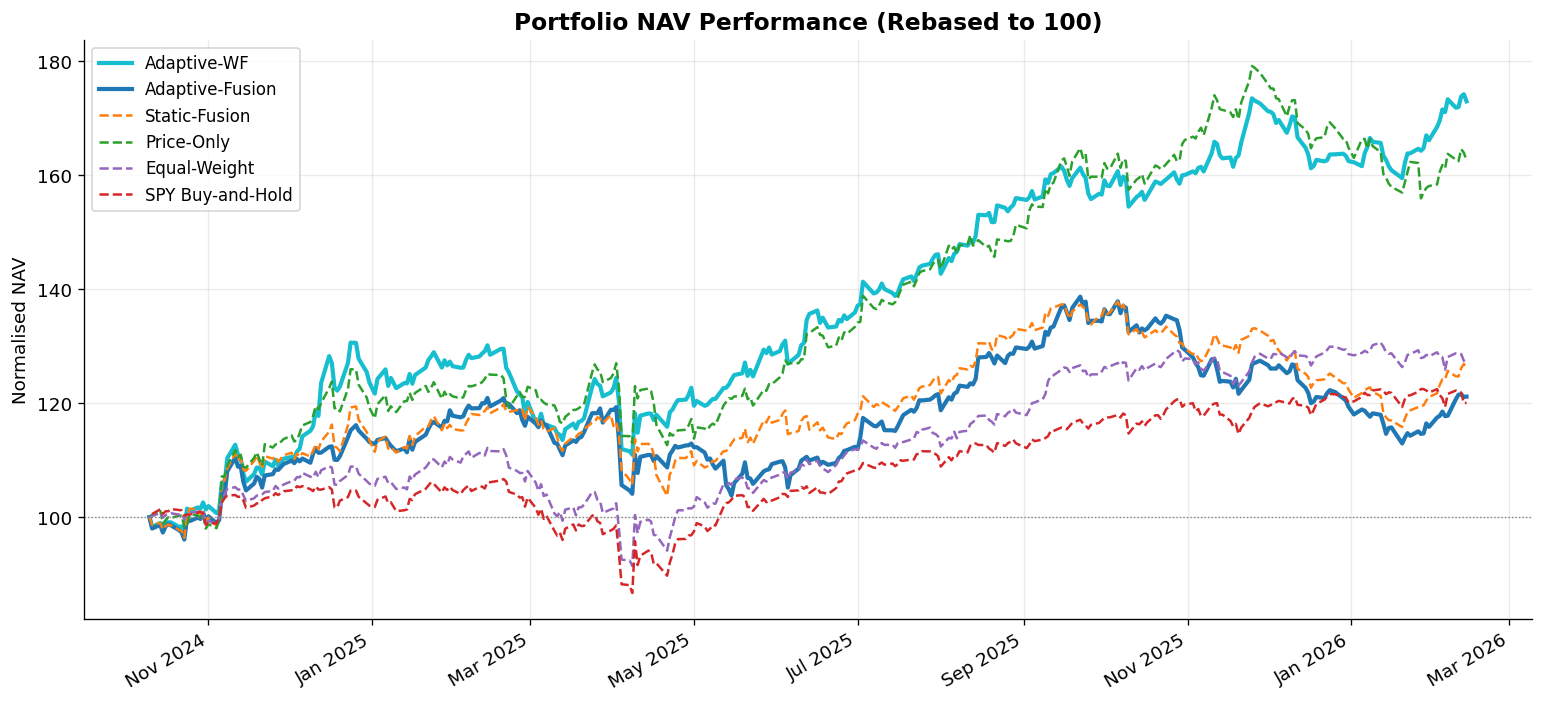

Figure 1 saved.


In [50]:
import matplotlib, matplotlib.pyplot as plt, matplotlib.dates as mdates
matplotlib.rcParams.update({"figure.dpi":120,"font.size":11,
    "axes.spines.top":False,"axes.spines.right":False})

COLORS = {"Adaptive-WF":      "#17becf",
          "Adaptive-Fusion":  "#1f77b4",
          "Static-Fusion":    "#ff7f0e",
          "Price-Only":       "#2ca02c",
          "Equal-Weight":     "#9467bd",
          "SPY Buy-and-Hold": "#d62728"}

def fmt_ax(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right"); ax.grid(True,alpha=.25)

# Figure 1: NAV
fig, ax = plt.subplots(figsize=(13, 6))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_rebased = (strategy_result.nav_series / INITIAL_NAV) * 100
    is_highlight = strategy_name in ("Adaptive-WF", "Adaptive-Fusion")
    ax.plot(nav_rebased.index, nav_rebased.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if is_highlight else 1.5,
            ls="-"  if is_highlight else "--")
ax.axhline(100, color="grey", lw=0.8, ls=":")
ax.set_title("Portfolio NAV Performance (Rebased to 100)", fontsize=14, fontweight="bold")
ax.set_ylabel("Normalised NAV"); fmt_ax(ax); ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"1_nav_comparison.png", dpi=300, bbox_inches="tight")
plt.show(); print("Figure 1 saved.")


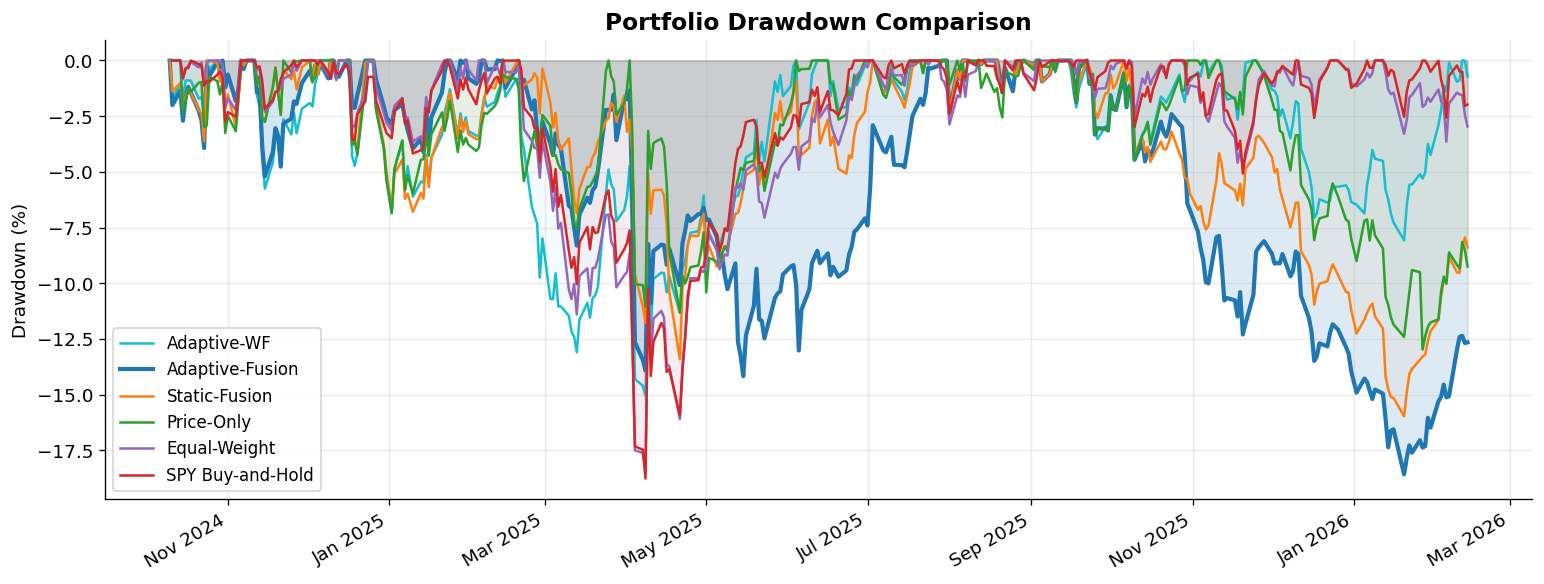

Figure 2 saved.


In [51]:
# Figure 2: Drawdown
fig, ax = plt.subplots(figsize=(13, 5))
for strategy_name, strategy_result in all_results.items():
    if strategy_result.nav_series.empty: continue
    nav_series = strategy_result.nav_series
    drawdown   = ((nav_series - nav_series.cummax()) / nav_series.cummax()) * 100
    ax.plot(drawdown.index, drawdown.values,
            label=strategy_name,
            color=COLORS[strategy_name],
            lw=2.5 if strategy_name == "Adaptive-Fusion" else 1.5)
    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color=COLORS[strategy_name],
                    alpha=0.15 if strategy_name == "Adaptive-Fusion" else 0.05)
ax.set_title("Portfolio Drawdown Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)"); fmt_ax(ax); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"2_drawdown_comparison.png", dpi=300, bbox_inches="tight")
plt.show(); print("Figure 2 saved.")

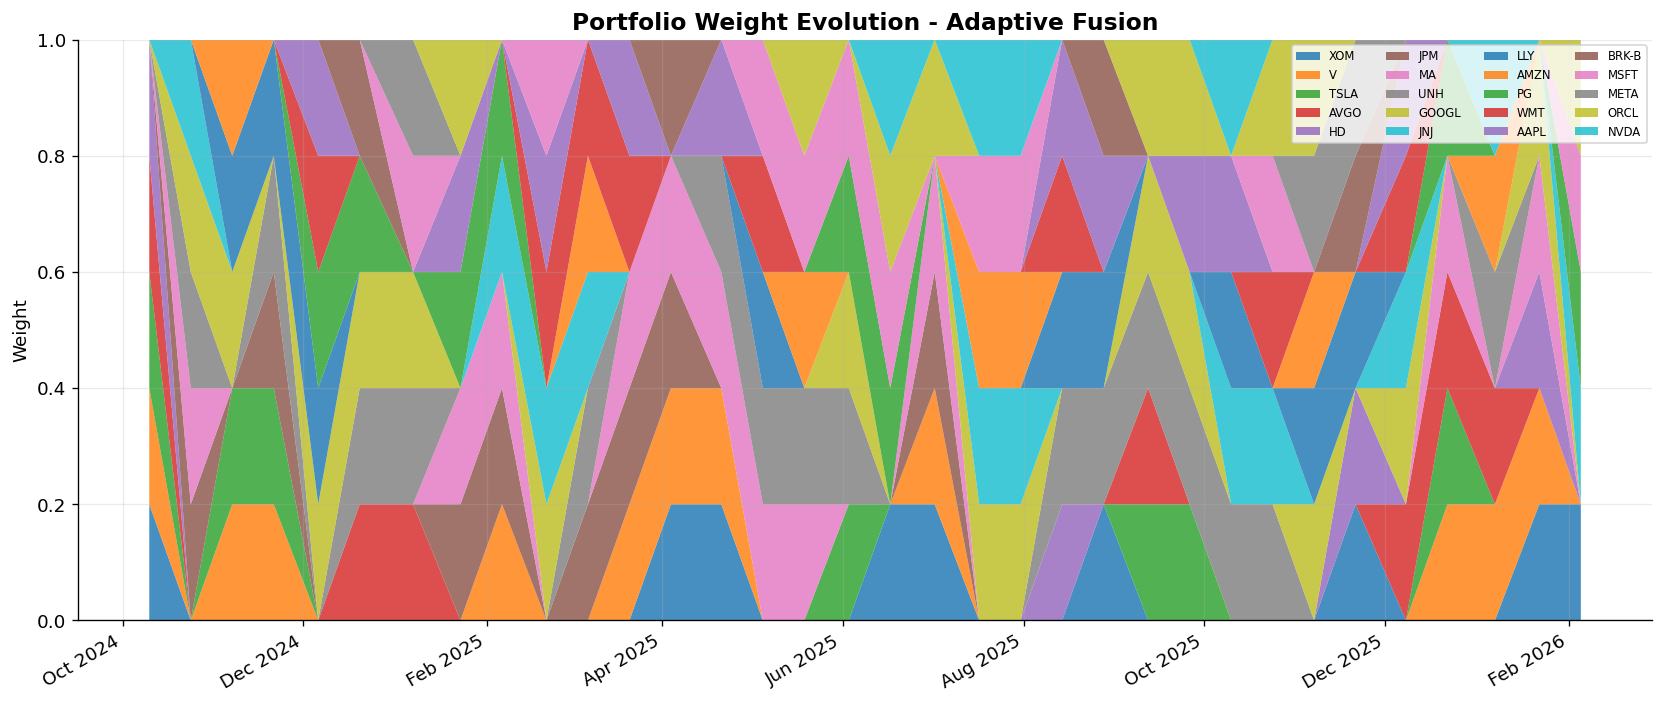

Figure 3 saved.


In [52]:
# Figure 3: Weight Evolution
if not adaptive_result.weight_history.empty:
    wh=adaptive_result.weight_history.fillna(0).clip(lower=0)
    all_tickers=wh.columns.tolist()
    fig,ax=plt.subplots(figsize=(14,6))
    ax.stackplot(wh.index,wh[all_tickers].T.values,labels=all_tickers,alpha=0.82)
    ax.set_title("Portfolio Weight Evolution - Adaptive Fusion",fontsize=14,fontweight="bold")
    ax.set_ylabel("Weight"); ax.set_ylim(0,1); ax.legend(loc="upper right",fontsize=7,ncol=4)
    fmt_ax(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"3_weight_evolution.png",dpi=300,bbox_inches="tight")
    plt.show(); print("Figure 3 saved.")

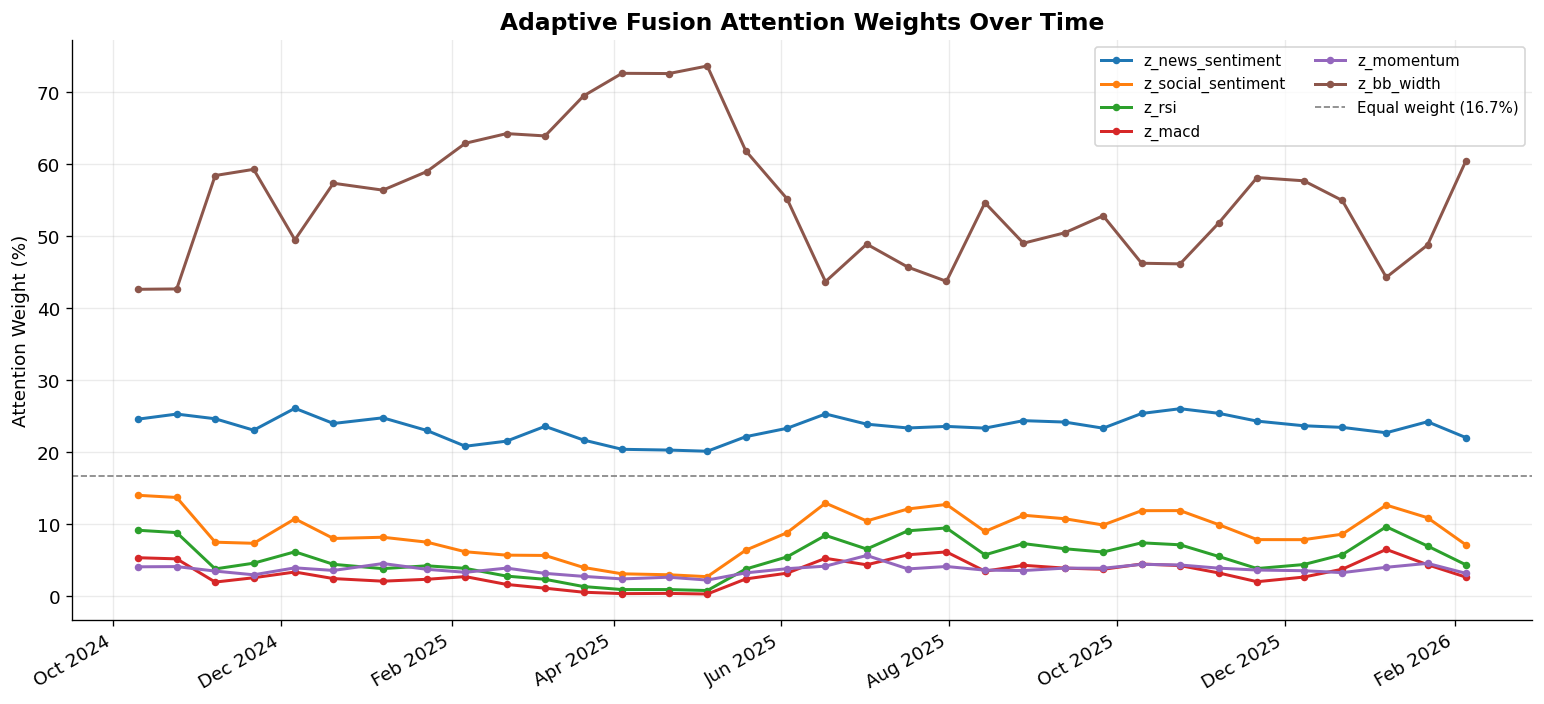

Figure 4 saved.


In [53]:
# Figure 4: Attention weights over time
rename = {"news_sentiment":"News Sentiment","social_sentiment":"Social Sentiment",
          "rsi":"RSI","macd":"MACD","momentum":"Momentum","bb_width":"BB Width"}
if adaptive_result.attention_history:
    attention_df = pd.DataFrame(adaptive_result.attention_history).set_index("date")
    attention_df.columns = [col.replace("attn_z_","").replace("attn_","") for col in attention_df.columns]
    attention_df = attention_df.rename(columns=rename)
    fig, ax = plt.subplots(figsize=(13, 6))
    color_map = plt.get_cmap("tab10")
    for factor_index, factor_name in enumerate(attention_df.columns):
        ax.plot(attention_df.index, attention_df[factor_name] * 100,
                label=factor_name, lw=1.8, marker="o", ms=3.5, color=color_map(factor_index))
    equal_weight_line = 100 / len(attention_df.columns)
    ax.axhline(equal_weight_line, color="grey", ls="--", lw=1,
               label=f"Equal weight ({equal_weight_line:.1f}%)")
    ax.set_title("Adaptive Fusion Attention Weights Over Time", fontsize=14, fontweight="bold")
    ax.set_ylabel("Attention Weight (%)")
    ax.legend(fontsize=9, ncol=2)
    fmt_ax(ax); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"4_attention_weights.png", dpi=300, bbox_inches="tight")
    plt.show(); print("Figure 4 saved.")

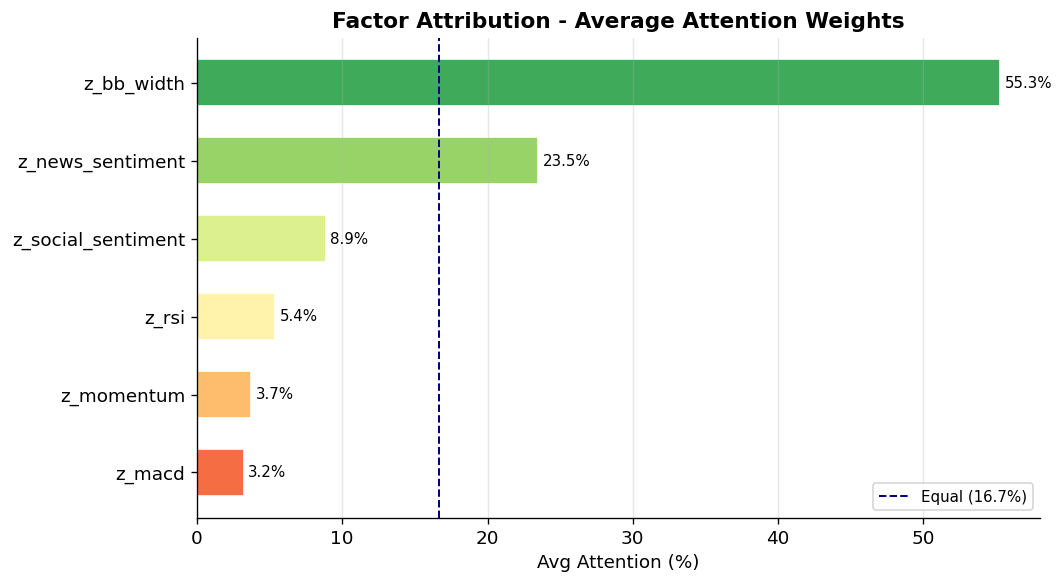

Figure 5 saved.


In [54]:
# Figure 5: Factor attribution
if adaptive_result.attention_history:
    attention_df = pd.DataFrame(adaptive_result.attention_history).drop(columns=["date"], errors="ignore")
    attention_df.columns = [col.replace("attn_z_","").replace("attn_","") for col in attention_df.columns]
    attention_df   = attention_df.rename(columns=rename)
    mean_attention = attention_df.mean().sort_values() * 100
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_colors = plt.get_cmap("RdYlGn")(np.linspace(0.2, 0.85, len(mean_attention)))
    bars = ax.barh(mean_attention.index, mean_attention.values,
                   color=bar_colors, edgecolor="white", height=0.6)
    equal_weight_pct = 100 / len(mean_attention)
    ax.axvline(equal_weight_pct, color="navy", lw=1.2, ls="--",
               label=f"Equal ({equal_weight_pct:.1f}%)")
    for bar, attention_value in zip(bars, mean_attention.values):
        ax.text(attention_value + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{attention_value:.1f}%", va="center", fontsize=9)
    ax.set_title("Factor Attribution - Average Attention Weights", fontsize=13, fontweight="bold")
    ax.set_xlabel("Avg Attention (%)")
    ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"5_factor_attribution.png", dpi=300, bbox_inches="tight")
    plt.show(); print("Figure 5 saved.")

In [55]:
# Metrics summary table
metric_rows = [{"Strategy": strategy_name, **strategy_result.metrics}
               for strategy_name, strategy_result in all_results.items()]
metrics_df  = pd.DataFrame(metric_rows).set_index("Strategy")
display_df  = metrics_df.copy()
for column_name in ["Annualised Return","Annualised Vol","Max Drawdown","Total Return"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x*100:+.2f}%")
for column_name in ["Sharpe Ratio","Calmar Ratio"]:
    if column_name in display_df:
        display_df[column_name] = display_df[column_name].map(lambda x: f"{x:.4f}")
print("\n" + "="*70)
print("STRATEGY PERFORMANCE SUMMARY")
print("="*70)
display(display_df)
print("="*70)
metrics_df.to_csv(OUTPUT_DIR/"metrics_summary.csv")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


STRATEGY PERFORMANCE SUMMARY


,Sharpe Ratio,Annualised Return,Annualised Vol,Max Drawdown,Calmar Ratio,Total Return
Strategy,,,,,,
Adaptive-WF,2.3376,+50.83%,+21.75%,-15.06%,3.3748,+72.98%
Adaptive-Fusion,0.7491,+15.48%,+20.66%,-18.57%,0.8333,+21.15%
Static-Fusion,0.9445,+19.11%,+20.23%,-15.96%,1.1972,+26.26%
Price-Only,1.9548,+44.00%,+22.51%,-12.97%,3.3923,+62.62%
Equal-Weight,1.0947,+19.41%,+17.73%,-18.48%,1.0499,+26.79%
SPY Buy-and-Hold,0.8213,+14.74%,+17.95%,-18.76%,0.7861,+19.41%



All outputs saved to: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs


In [56]:
# Adaptive Fusion trade log
trade_log_df = pd.DataFrame(adaptive_result.trade_log)
trade_log_df["date"] = pd.to_datetime(trade_log_df["date"])
trade_log_df = trade_log_df.sort_values(["date", "ticker"]).reset_index(drop=True)
trade_log_df["shares"] = trade_log_df["shares"].round(6)
trade_log_df["price"]  = trade_log_df["price"].round(4)
trade_log_df["value"]  = trade_log_df["value"].round(2)

trade_log_df.to_csv(OUTPUT_DIR / "adaptive_fusion_trade_log.csv", index=False)

print(f"Total trades : {len(trade_log_df)}")
print(f"Buys         : {(trade_log_df['action']=='BUY').sum()}")
print(f"Sells        : {(trade_log_df['action']=='SELL').sum()}")
print(f"Tickers      : {sorted(trade_log_df['ticker'].unique())}")
print(f"\nSaved: {OUTPUT_DIR / 'adaptive_fusion_trade_log.csv'}")
print()
display(trade_log_df)

Total trades : 275
Buys         : 135
Sells        : 140
Tickers      : ['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NVDA', 'ORCL', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']

Saved: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\portfolio_optimizer\outputs\adaptive_fusion_trade_log.csv



,date,ticker,action,shares,price,value
0,2024-10-10,AVGO,BUY,11.018025,181.5207,2000.00
1,2024-10-10,HD,BUY,5.026914,397.8584,2000.00
2,2024-10-10,TSLA,BUY,8.266823,241.9309,2000.00
3,2024-10-10,V,BUY,7.302497,273.8789,2000.00
4,2024-10-10,XOM,BUY,17.077963,117.1100,2000.00
...,...,...,...,...,...,...
270,2026-02-05,MSFT,BUY,5.789003,406.7154,2354.48
271,2026-02-05,ORCL,BUY,16.162775,145.6728,2354.48
272,2026-02-05,PG,BUY,14.815539,158.9194,2354.48
273,2026-02-05,V,SELL,7.040415,332.4809,2340.80


## 12. Rolling Window Analysis

Tests whether strategy performance is sensitive to the choice of backtest entry date.
The fixed trained model (no retraining) is run across every 1-year window
whose start date falls between 2025-02-10 and 2026-02-16, stepping one trading day at a time.

| Metric tracked | Interpretation |
|----------------|----------------|
| Sharpe ratio per window | Is edge consistent or clustered in one period? |
| % windows beating SPY | Reliability of outperformance across entry dates |
| Total return distribution | Sensitivity to starting conditions |

In [57]:
def _metrics_from_rets(rets):
    """Compute Sharpe and Total Return from a 1-D array of daily returns."""
    rets = rets[~np.isnan(rets)]
    if len(rets) < 2:
        return {"Sharpe": np.nan, "Total Return": np.nan}
    ann_ret = (1 + rets).prod() ** (252 / len(rets)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0.0
    total   = (1 + rets).prod() - 1
    return {"Sharpe": round(sharpe, 4), "Total Return": round(total, 4)}


ROLL_START_RANGE = BACKTEST_START
ROLL_END_RANGE   = "2026-02-16"  # last window START date; each window ends +1 year

# Fetch SPY for the full rolling period (wider than original spy_returns)
print("Fetching extended SPY returns")
spy_wide = fetch_spy_returns(BACKTEST_START, ROLL_END_RANGE)

# Trading dates that fall in the start-date range
all_trading = sorted(price_data[TICKERS[0]].index)
window_starts = [
    d for d in all_trading
    if pd.Timestamp(ROLL_START_RANGE) <= d <= pd.Timestamp(ROLL_END_RANGE)
]
oos_boundary = pd.Timestamp(BACKTEST_START)   # in-sample / OOS split

print(f"Windows          : {len(window_starts)}")
print(f"Start range      : {window_starts[0].date()}  to  {window_starts[-1].date()}")
print(f"OOS boundary     : {oos_boundary.date()}")
print(f"In-sample windows: {sum(d < oos_boundary for d in window_starts)}")
print(f"OOS windows      : {sum(d >= oos_boundary for d in window_starts)}")
print()

rolling_records = []

for i, start_dt in enumerate(window_starts, 1):
    end_dt    = start_dt + pd.DateOffset(years=1)
    start_str = start_dt.strftime("%Y-%m-%d")
    end_str   = end_dt.strftime("%Y-%m-%d")

    try:
        r = run_backtest(
            f"AF_{start_str}", feature_data, price_data,
            model=fusion_model, use_sentiment=True, use_adaptive=True,
            start=start_str, end=end_str
        )
        m = r.metrics
    except Exception as e:
        print(f"  [{i:3d}] {start_str} FAILED: {e}")
        continue

    if not m:
        print(f"  [{i:3d}] {start_str} SKIPPED: backtest returned empty metrics (too few trading days)")
        continue

    spy_w = spy_wide.loc[start_str:end_str].dropna()
    spy_m = _metrics_from_rets(spy_w.values) if len(spy_w) >= 20 else None

    rolling_records.append({
        "start":            start_dt,
        "end":              end_dt,
        "in_sample":        start_dt < oos_boundary,
        "AF_Sharpe":        m["Sharpe Ratio"],
        "AF_Total_Return":  m["Total Return"],
        "AF_Ann_Return":    m["Annualised Return"],
        "AF_Max_Drawdown":  m["Max Drawdown"],
        "SPY_Sharpe":       spy_m["Sharpe"]       if spy_m else np.nan,
        "SPY_Total_Return": spy_m["Total Return"] if spy_m else np.nan,
    })

    if i % 10 == 0 or i == len(window_starts):
        tag = "IS" if start_dt < oos_boundary else "OOS"
        spy_s = rolling_records[-1]["SPY_Sharpe"]
        print(f"  [{i:3d}/{len(window_starts)}] {start_str} [{tag}]  "
              f"AF={m['Sharpe Ratio']:+.3f}  SPY={spy_s:+.3f}")

rolling_df = pd.DataFrame(rolling_records)
rolling_df["beats_spy"] = rolling_df["AF_Sharpe"] > rolling_df["SPY_Sharpe"]

# Summary
print(f"\nRolling Window Summary")
print("=" * 60)
for label, mask in [("All windows", slice(None)),
                     ("In-sample windows",  rolling_df["in_sample"]),
                     ("Out-of-sample only", ~rolling_df["in_sample"])]:
    sub = rolling_df[mask] if isinstance(mask, pd.Series) else rolling_df
    if len(sub) == 0:
        continue
    cols = ["AF_Sharpe", "AF_Total_Return", "AF_Max_Drawdown"]
    desc = sub[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    print(f"\n{label}  (n={len(sub)}):")
    display(desc.round(4))
    print(f"  Pct windows beating SPY : {sub['beats_spy'].mean():.1%}")

Fetching extended SPY returns
Windows          : 337
Start range      : 2024-10-10  to  2026-02-13
OOS boundary     : 2024-10-10
In-sample windows: 0
OOS windows      : 337

[AF_2024-10-10       ] Sharpe=+1.483 | Return=+32.5% | MaxDD=-14.2%
[AF_2024-10-11       ] Sharpe=+2.302 | Return=+55.0% | MaxDD=-11.2%
[AF_2024-10-14       ] Sharpe=+1.264 | Return=+28.6% | MaxDD=-13.2%
[AF_2024-10-15       ] Sharpe=+2.206 | Return=+51.3% | MaxDD=-15.0%
[AF_2024-10-16       ] Sharpe=+2.659 | Return=+54.7% | MaxDD=-11.2%
[AF_2024-10-17       ] Sharpe=+3.613 | Return=+80.5% | MaxDD=-12.1%
[AF_2024-10-18       ] Sharpe=+4.233 | Return=+88.5% | MaxDD=-8.2%
[AF_2024-10-21       ] Sharpe=+2.792 | Return=+61.4% | MaxDD=-12.8%
[AF_2024-10-22       ] Sharpe=+2.771 | Return=+60.9% | MaxDD=-12.2%
[AF_2024-10-23       ] Sharpe=+1.065 | Return=+23.5% | MaxDD=-11.4%
  [ 10/337] 2024-10-23 [OOS]  AF=+1.065  SPY=+0.849
[AF_2024-10-24       ] Sharpe=+1.667 | Return=+35.8% | MaxDD=-14.2%
[AF_2024-10-25       ] Shar

,AF_Sharpe,AF_Total_Return,AF_Max_Drawdown
count,335.0000,335.0000,335.0000
mean,2.9295,0.2539,-0.0941
std,5.0613,0.2133,0.0413
min,-1.9351,-0.1182,-0.1857
5%,-0.1135,-0.0081,-0.1823
25%,1.1366,0.0574,-0.1208
50%,2.1869,0.2288,-0.0869
75%,3.1590,0.3986,-0.0670
95%,6.8830,0.6150,-0.0218
max,57.3693,1.0914,0.0000


  Pct windows beating SPY : 74.3%

Out-of-sample only  (n=335):


,AF_Sharpe,AF_Total_Return,AF_Max_Drawdown
count,335.0000,335.0000,335.0000
mean,2.9295,0.2539,-0.0941
std,5.0613,0.2133,0.0413
min,-1.9351,-0.1182,-0.1857
5%,-0.1135,-0.0081,-0.1823
25%,1.1366,0.0574,-0.1208
50%,2.1869,0.2288,-0.0869
75%,3.1590,0.3986,-0.0670
95%,6.8830,0.6150,-0.0218
max,57.3693,1.0914,0.0000


  Pct windows beating SPY : 74.3%


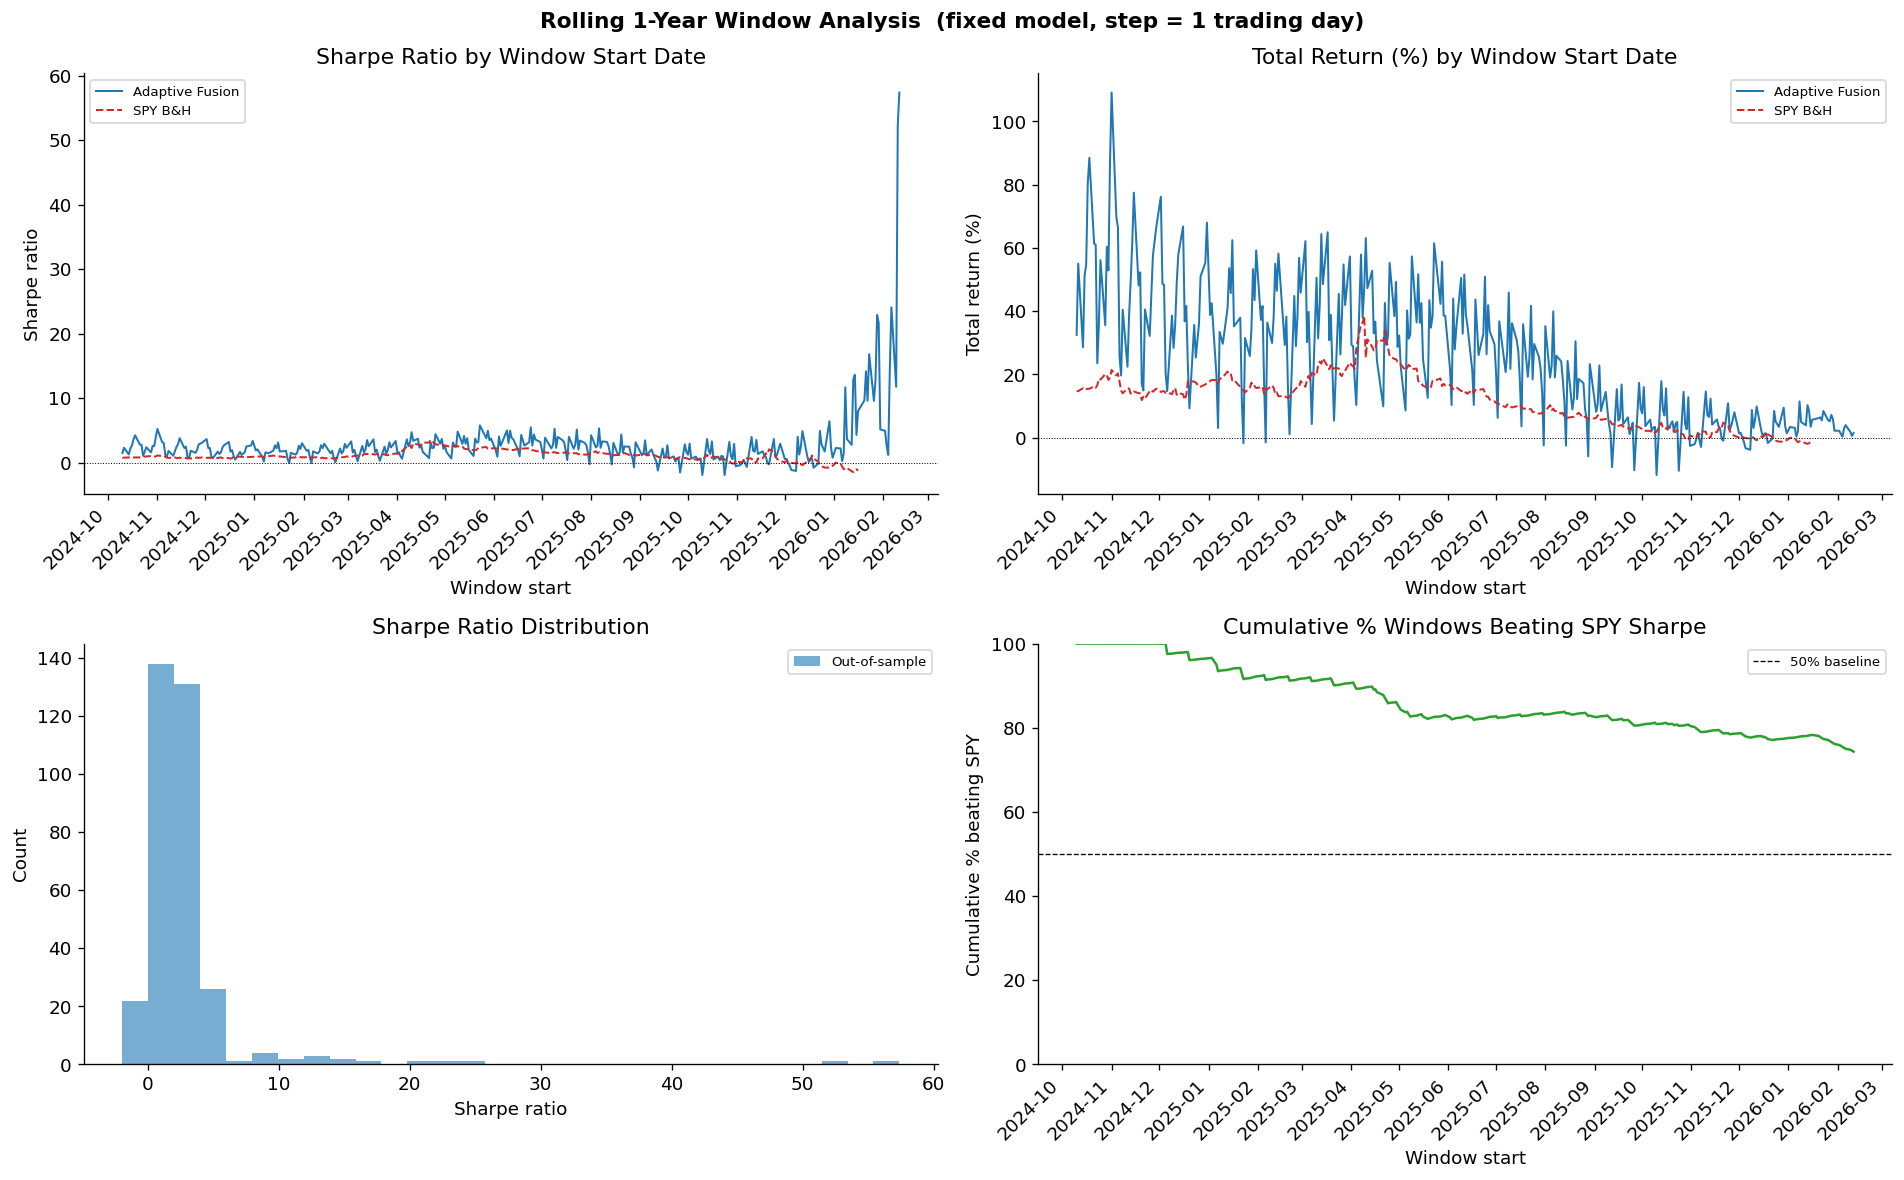

In [58]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Rolling 1-Year Window Analysis  (fixed model, step = 1 trading day)",
             fontsize=13, fontweight="bold")

is_mask  = rolling_df["in_sample"]
oos_mask = ~rolling_df["in_sample"]

def _apply_month_fmt(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Top-left: Sharpe ratio
ax = axes[0, 0]
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange", label="In-sample region")
ax.plot(rolling_df["start"], rolling_df["AF_Sharpe"],
        color="#1f77b4", linewidth=1.2, label="Adaptive Fusion")
ax.plot(rolling_df["start"], rolling_df["SPY_Sharpe"],
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Sharpe Ratio by Window Start Date")
ax.set_xlabel("Window start")
ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Top-right: Total return
ax = axes[0, 1]
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange")
ax.plot(rolling_df["start"], rolling_df["AF_Total_Return"] * 100,
        color="#1f77b4", linewidth=1.2, label="Adaptive Fusion")
ax.plot(rolling_df["start"], rolling_df["SPY_Total_Return"] * 100,
        color="#d62728", linewidth=1.2, linestyle="--", label="SPY B&H")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title("Total Return (%) by Window Start Date")
ax.set_xlabel("Window start")
ax.set_ylabel("Total return (%)")
ax.legend(fontsize=8)
_apply_month_fmt(ax)

# Bottom-left: Sharpe histogram (IS vs OOS)
ax = axes[1, 0]
bins = 30
if is_mask.any():
    ax.hist(rolling_df.loc[is_mask,  "AF_Sharpe"], bins=bins,
            alpha=0.6, color="orange", label="In-sample")
if oos_mask.any():
    ax.hist(rolling_df.loc[oos_mask, "AF_Sharpe"], bins=bins,
            alpha=0.6, color="#1f77b4", label="Out-of-sample")
ax.set_title("Sharpe Ratio Distribution")
ax.set_xlabel("Sharpe ratio")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# Bottom-right: Cumulative % windows beating SPY
ax = axes[1, 1]
cum_beat = rolling_df["beats_spy"].expanding().mean() * 100
if is_mask.any():
    ax.axvspan(rolling_df.loc[is_mask, "start"].min(),
               rolling_df.loc[is_mask, "start"].max(),
               alpha=0.10, color="orange", label="In-sample region")
ax.plot(rolling_df["start"], cum_beat,
        color="#2ca02c", linewidth=1.5)
ax.axhline(50, color="black", linewidth=0.8, linestyle="--", label="50% baseline")
ax.set_title("Cumulative % Windows Beating SPY Sharpe")
ax.set_xlabel("Window start")
ax.set_ylabel("Cumulative % beating SPY")
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
_apply_month_fmt(ax)

plt.tight_layout()
plt.show()